<a href="https://colab.research.google.com/github/zry3fr/undergrad_ml_assignments/blob/main/COMPLETE_genomics_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.



In [1]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 79 (delta 29), reused 12 (delta 12), pack-reused 39 (from 2)
Receiving objects: 100% (79/79), 11.71 MiB | 15.84 MiB/s, done.
Resolving deltas: 100% (29/29), done.


# 1.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path, Lasso, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler

golub = pd.read_csv('./undergrad_ml_assignments/data/golub.csv')
print(golub.head())

mapper = {'allB':0,
          'allT':0,
          'aml':1}

golub['outcome'] = golub['cancer'].map(mapper)

   Samples BM.PB Gender Source tissue.mf cancer  AFFX-BioB-5_at  \
0       39    BM      F   DFCI      BM:f   allB    -1363.276427   
1       40    BM      F   DFCI      BM:f   allB     -796.285053   
2       42    BM      F   DFCI      BM:f   allB     -679.139168   
3       47    BM      M   DFCI      BM:m   allB    -1164.400197   
4       48    BM      F   DFCI      BM:f   allB    -1299.653758   

   AFFX-BioB-M_at  AFFX-BioB-3_at  AFFX-BioC-5_at  ...   U48730_at  \
0    -1058.585495     -541.469194       74.349803  ...  -35.081447   
1    -1167.103365        7.538493       83.544731  ... -404.737767   
2    -1069.832308     -690.301829     -112.075981  ...  193.780934   
3    -1109.939891     -990.127218     -238.574994  ... -256.002292   
4    -1401.998536    -1077.543813     -437.344560  ... -509.203660   

     U58516_at    U73738_at   X06956_at    X16699_at    X83863_at   Z17240_at  \
0  1565.618803  -485.680714 -170.261227  -919.114293  1675.050053  389.769289   
1   622.498054

# 2. Straight linear regression

OLS training MSE: 1.2522824482837894e-30


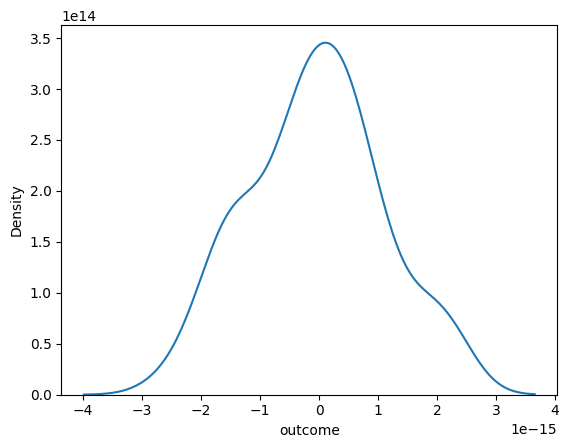

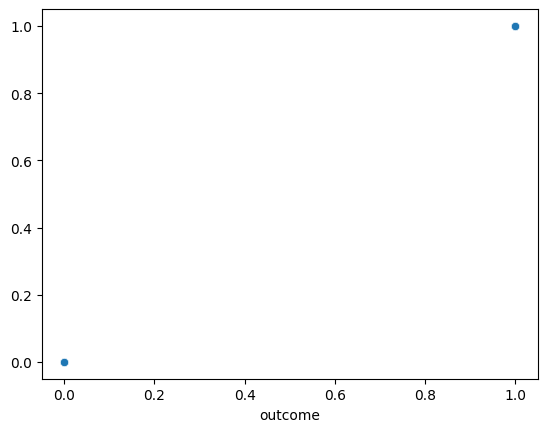

In [4]:
mse = lambda y,y_hat : np.mean( (y-y_hat)**2 )

y = golub['outcome']
X = golub.drop(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer','outcome'],axis=1)

model = LinearRegression()
reg = model.fit(X,y)

y_hat = reg.predict(X)
print(f'OLS training MSE: {mse(y,y_hat)}')

residuals = y_hat - y
sns.kdeplot(residuals)
plt.show()
residuals.describe()

sns.scatterplot(x=y,y=y_hat)
plt.show()

# 3. Cross validation of the linear model

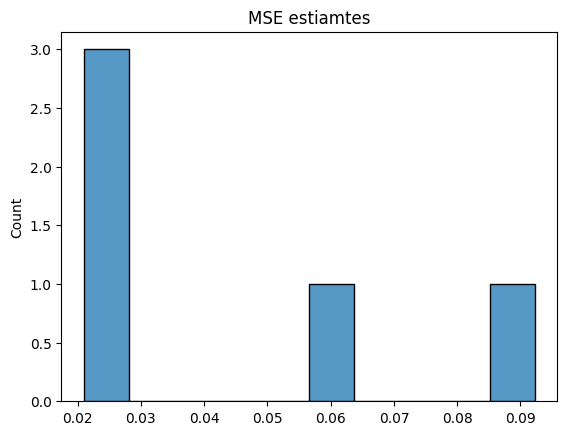

Fold scores: [0.0244198  0.05792023 0.09224999 0.02097934 0.02126042]
Mean score: 0.04336595898622785
Median score: 0.024419803797537328
Std dev: 0.028107820694269984


In [5]:
kfold = KFold(n_splits=5, shuffle=True, random_state=100) # Create folds
scores = cross_val_score( # Conduct kfcv:
    model,X,y, # Model and data
    cv=kfold, # Folds
    scoring='neg_mean_squared_error' # Loss function
)

mse = -scores

sns.histplot(mse,bins=10).set(title='MSE estiamtes')
plt.show()

print("Fold scores:", mse)
print("Mean score:", np.mean(mse))
print("Median score:", np.median(mse))
print("Std dev:", np.std(mse))

The average cross validation MSE is about 0.043 and the scores vary quite a bit across the different folds. Even though the model fits the training data almost perfectly (the training MSE is 1.25 x 10*-30), it does worse on new data. This means the model is overfitting. In terms of the bias variance trade-off, the model has low bias (it fits the training data very well) but high variance (its performance changes a lot depending on the data).

# 4. Cross-Validated Lasso

In [7]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

alpha_grid = np.logspace(-3, 0, 50)
model = LassoCV(
    cv=10,
    alphas=alpha_grid,
    random_state=100,
    max_iter=50000,
    tol=1e-3
)

model.fit(X_sc, y)

alpha_star = model.alpha_
index_star = np.argmin(np.mean(model.mse_path_, axis=1))
lasso_final = Lasso(alpha=alpha_star, max_iter=50000)
lasso_final.fit(X_sc, y)
coefs_star = lasso_final.coef_

In [9]:
selected_genes = X.columns[coefs_star != 0]
print("Selected genes:", selected_genes)

Selected genes: Index(['AF000560_at', 'AF006087_at', 'D26579_at', 'D29956_at', 'D50840_at',
       'D86982_at', 'HG2161-HT2231_at', 'J04164_at', 'L13278_at', 'M17754_at',
       'M19507_at', 'M20902_at', 'M22960_at', 'M23197_at', 'M27819_at',
       'M27891_at', 'M28713_at', 'M31994_at', 'M34344_at', 'M63138_at',
       'M84526_at', 'M95178_at', 'M96326_rna1_at', 'M98539_at', 'U10868_at',
       'U14588_at', 'U30828_at', 'U34877_at', 'U36621_cds2_at', 'U46751_at',
       'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U82313_at', 'U82759_at',
       'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at', 'X53331_at',
       'X56741_at', 'X63753_at', 'X66533_at', 'X69111_at', 'X81479_at',
       'X83378_at', 'X95735_at', 'X96698_at', 'Y07604_at', 'Y07755_at',
       'Y10207_at', 'Y12670_at', 'M96843_at', 'X58072_at', 'AC002477_s_at',
       'L15326_s_at', 'X57351_at', 'U37055_rna1_s_at', 'X07438_s_at',
       'M13690_s_at', 'M26708_s_at', 'M84371_rna1_s_at', 'X12876_s_at',
       'U26312_s_at'

In [10]:
num_selected = np.sum(coefs_star != 0)
num_discarded = np.sum(coefs_star == 0)

print("Selected genes:", num_selected)
print("Discarded genes:", num_discarded)

Selected genes: 68
Discarded genes: 7061


The Lasso model selected X genes with non-zero coefficients and discarded Y genes by shrinking their coefficients to zero. This shows that Lasso performs selection by keeping only the most predictive genes.

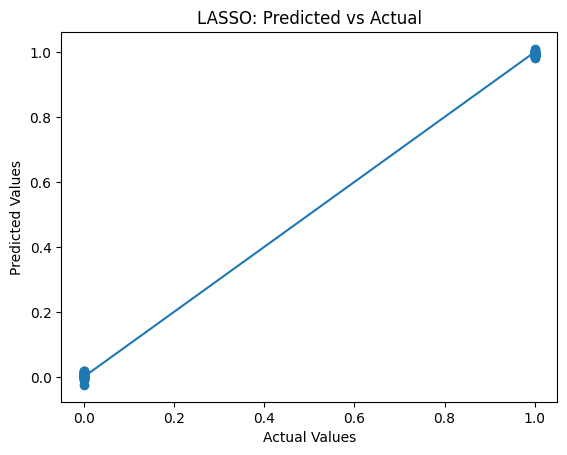

In [11]:
import matplotlib.pyplot as plt

y_pred_lasso = lasso_final.predict(X_sc)

plt.scatter(y, y_pred_lasso)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("LASSO: Predicted vs Actual")
plt.plot([0,1], [0,1])
plt.show()

# 5. Cross validated MSE versus alpha

Optimal cost hyperparameter: 0.0020235896477251575


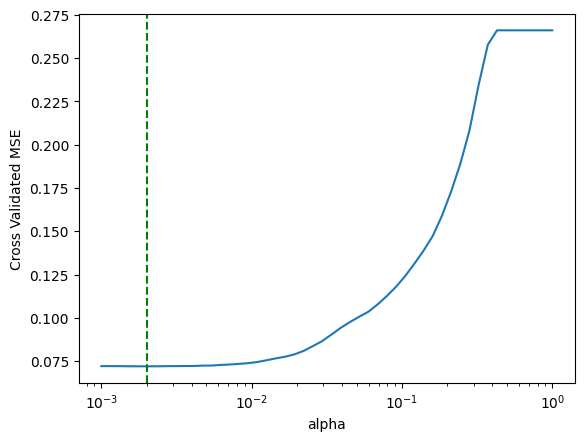

In [12]:
sns.lineplot( x=model.alphas_, y= np.mean(model.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='green', linestyle='--',
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')
plt.show()

For larger values of a (around 10*-1 to 1), the model is underfitting, because the penalty is too strong and most coefficients shrink toward zero, making the model too simple. For smaller values of a (around 10*-3 and below), the model is overfitting, because the penalty is too weak and the model acts like an ordinary linear regression, fitting the data closely. The optimal penalty hyperparameter is about 0.0020, which minimizes the expected MSE. This value provides the best balance between overfitting and underfitting.

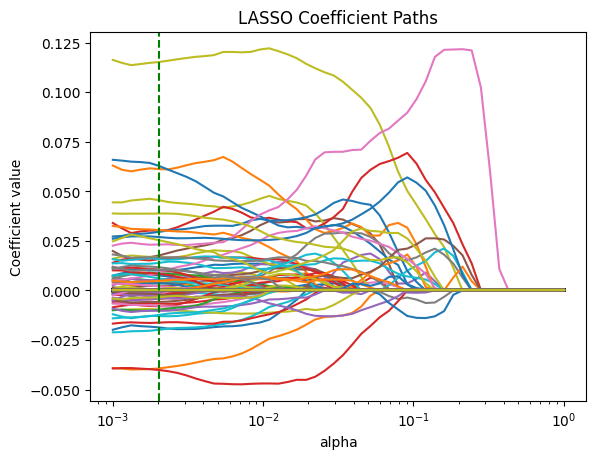

In [13]:
coefs = []
for alpha in model.alphas_: # For each alpha value,
    reg = Lasso(alpha=alpha, max_iter=10_000) # Create a lasso model
    reg = reg.fit(X_sc,y) # Run the regression
    coefs.append(reg.coef_) # Save the slope coefficients
coefs = np.array(coefs) # Cast list of lists to array

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(model.alphas_, coefs[:, i], label=X.columns[i]) # Switched in poly_names
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.show()

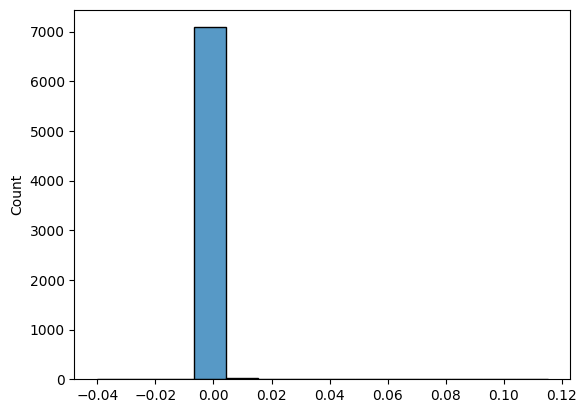

Selected Genes:
 Index(['AF000560_at', 'AF006087_at', 'D26579_at', 'D29956_at', 'D50840_at',
       'D86982_at', 'HG2161-HT2231_at', 'J04164_at', 'L13278_at', 'M17754_at',
       'M19507_at', 'M20902_at', 'M22960_at', 'M23197_at', 'M27819_at',
       'M27891_at', 'M28713_at', 'M31994_at', 'M34344_at', 'M63138_at',
       'M84526_at', 'M95178_at', 'M96326_rna1_at', 'M98539_at', 'U10868_at',
       'U14588_at', 'U30828_at', 'U34877_at', 'U36621_cds2_at', 'U46751_at',
       'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U82313_at', 'U82759_at',
       'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at', 'X53331_at',
       'X56741_at', 'X63753_at', 'X66533_at', 'X69111_at', 'X81479_at',
       'X83378_at', 'X95735_at', 'X96698_at', 'Y07604_at', 'Y07755_at',
       'Y10207_at', 'Y12670_at', 'M96843_at', 'X58072_at', 'AC002477_s_at',
       'L15326_s_at', 'X57351_at', 'U37055_rna1_s_at', 'X07438_s_at',
       'M13690_s_at', 'M26708_s_at', 'M84371_rna1_s_at', 'X12876_s_at',
       'U26312_s_at

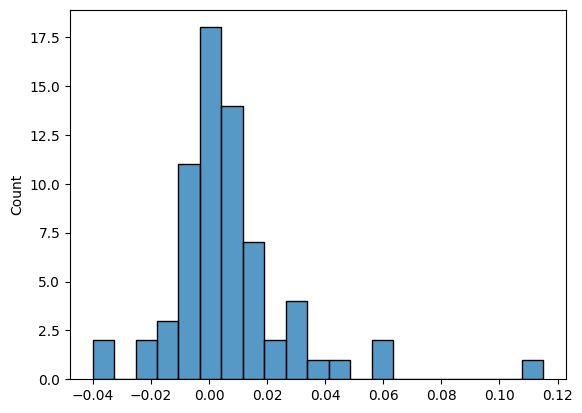

Nonzero coefficients: 68
Total genes: 7129


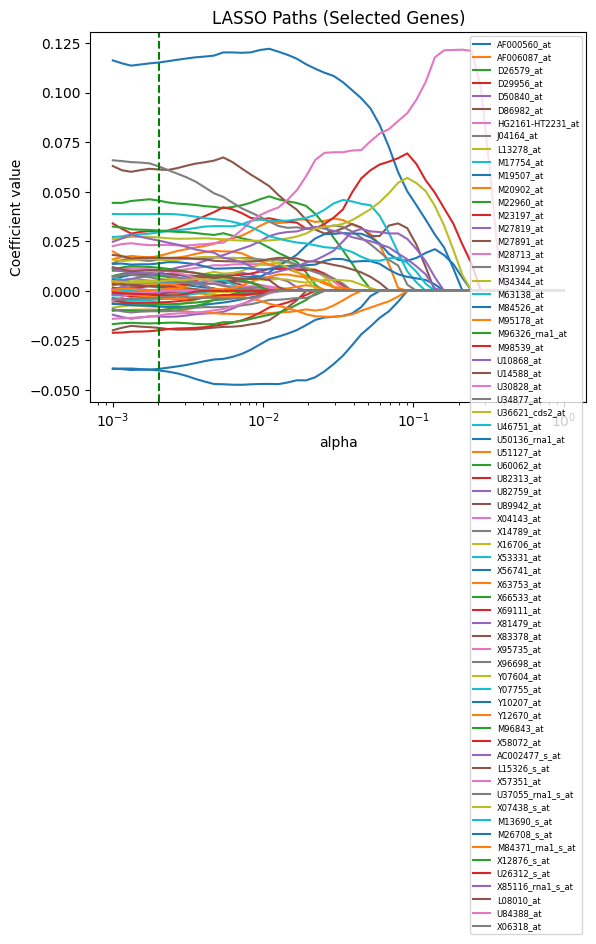

In [14]:
coefs_star = coefs[index_star]
sns.histplot( coefs_star )
plt.show()

nonzero_indices = np.where( coefs_star != 0 )
print('Selected Genes:\n', X.columns[nonzero_indices])
sns.histplot( coefs_star[nonzero_indices] )
plt.show()

print("Nonzero coefficients:", np.sum(coefs_star != 0))
print("Total genes:", len(coefs_star))

for i in nonzero_indices:
    plt.plot(model.alphas_, coefs[:, i], label=X.columns[i])

plt.xscale("log")
plt.axvline(alpha_star, linestyle="--", color="green")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Paths (Selected Genes)")
plt.legend(fontsize=6)
plt.show()

# 6.

Linear regression performs perfectly on the training data because there are far more genes than patients, allowing the model to exactly memorize the data. This leads to near zero training error. However, this causes overfitting, meaning the model does not capture true patterns and does not work well on new data. The Lasso simplifies the model by keeping only the most important genes and shrinks many coefficients to zero, which makes its predictions more reliable. This prevents overfitting and leads to better predictions on new data.

# 7.

Regularization methods like Lasso are well suited for precision health because these datasets often have many more variables (genes) than observations (patients). Regularization helps by selecting only the most important features, leading to simpler and more interpretable models that generalize better. This is important for making reliable predictions about patient outcomes.

#8.

While Lasso can improve prediction accuracy, it also has risks. It may discard genes that are actually important but appear weak in the data, leading to misleading conclusions. The model may also be sensitive to the specific dataset used, meaning results may not generalize well to different populations of patients. In precision health, these errors can have serious consequences as decisions based on the model could affect patient treatment.